## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
import tensorflow as tf

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [68]:
print('X Train Shape - ', x_train.shape)
print('Y Train Shape - ', y_train.shape)


X Train Shape -  (60000, 28, 28)
Y Train Shape -  (60000,)


In [69]:
print('X Test Shape - ', x_test.shape)
print('Y Test Shape - ', y_test.shape)

X Test Shape -  (10000, 28, 28)
Y Test Shape -  (10000,)


### Find dimensions of an image in the dataset

In [70]:
x_train[0].shape

(28, 28)

Image width and height both are 28

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train / 255.0

In [0]:
x_test = x_test / 255.0

In [25]:
x_test[0][0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [78]:
x_train.shape[0]

60000

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train = x_train.reshape(x_train.shape[0],28,28,1)

In [81]:
x_train[0].shape

(28, 28, 1)

In [0]:
x_test = x_test.reshape(x_test.shape[0],28,28,1)

### Import the necessary layers from keras to build the model

In [82]:
model = tf.keras.models.Sequential()
#model.add(tf.keras.layers.BatchNormalization(input_shape=(img_size,img_size,3,)))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#model.add(tf.keras.layers.Dropout(0.25))

W0818 09:49:14.577884 140182870824832 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_acc',patience=5)

In [101]:
model.fit(x_train,y_train,          
          validation_data=(x_test,y_test),
          epochs=10,
          batch_size=32,callbacks=[es])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 134us/sample - loss: 0.0066 - acc: 0.9981 - val_loss: 1.0951 - val_acc: 0.9136
Epoch 2/10
60000/60000 [==============================] - 8s 130us/sample - loss: 0.0082 - acc: 0.9978 - val_loss: 1.2330 - val_acc: 0.9085
Epoch 3/10
60000/60000 [==============================] - 8s 130us/sample - loss: 0.0077 - acc: 0.9978 - val_loss: 1.1495 - val_acc: 0.9131
Epoch 4/10
60000/60000 [==============================] - 8s 131us/sample - loss: 0.0072 - acc: 0.9982 - val_loss: 1.1489 - val_acc: 0.9120
Epoch 5/10
60000/60000 [==============================] - 8s 131us/sample - loss: 0.0063 - acc: 0.9983 - val_loss: 1.2167 - val_acc: 0.9068
Epoch 6/10
60000/60000 [==============================] - 8s 131us/sample - loss: 0.0082 - acc: 0.9979 - val_loss: 1.2256 - val_acc: 0.9042


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.BatchNormalization())
model1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model1.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(tf.keras.layers.Dropout(0.25))
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dense(128, activation='relu'))
model1.add(tf.keras.layers.Dense(10, activation='softmax'))


In [116]:
model1.fit(x_train,y_train,          
          validation_data=(x_test,y_test),
          epochs=10,
          batch_size=32,callbacks=[es])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 9s 143us/sample - loss: 0.3614 - acc: 0.8698 - val_loss: 0.2787 - val_acc: 0.9035
Epoch 2/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.2287 - acc: 0.9154 - val_loss: 0.2381 - val_acc: 0.9140
Epoch 3/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.1806 - acc: 0.9330 - val_loss: 0.2301 - val_acc: 0.9156
Epoch 4/10
60000/60000 [==============================] - 8s 137us/sample - loss: 0.1465 - acc: 0.9458 - val_loss: 0.2213 - val_acc: 0.9201
Epoch 5/10
60000/60000 [==============================] - 8s 137us/sample - loss: 0.1192 - acc: 0.9561 - val_loss: 0.2353 - val_acc: 0.9203
Epoch 6/10
60000/60000 [==============================] - 8s 138us/sample - loss: 0.1001 - acc: 0.9621 - val_loss: 0.2503 - val_acc: 0.9229
Epoch 7/10
60000/60000 [==============================] - 8s 139us/sample - loss: 0.0819 - acc: 0.9690 - val_l

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
transform_fn = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                               width_shift_range=0.2,
                                                               height_shift_range=0.2,
                                                               rotation_range=30,
                                                               shear_range=0.2,
                                                               zoom_range=0.3)
transform_fn.fit(x_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

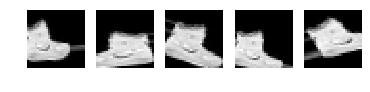

In [113]:
from matplotlib import pyplot as plt
gen = transform_fn.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
batchsize = 64


In [123]:
model1.fit_generator(transform_fn.flow(x_train, y_train, batch_size=batchsize),validation_data=(x_test, y_test), steps_per_epoch=len(x_train) // batchsize,	epochs=10)

Epoch 1/10
937/937 [==============================] - 16s 17ms/step - loss: 1.0057 - acc: 0.6361 - val_loss: 0.5492 - val_acc: 0.7868
Epoch 2/10
937/937 [==============================] - 16s 17ms/step - loss: 0.7138 - acc: 0.7357 - val_loss: 0.5257 - val_acc: 0.7975
Epoch 3/10
937/937 [==============================] - 16s 17ms/step - loss: 0.6464 - acc: 0.7607 - val_loss: 0.5351 - val_acc: 0.8108
Epoch 4/10
937/937 [==============================] - 16s 17ms/step - loss: 0.6067 - acc: 0.7756 - val_loss: 0.5557 - val_acc: 0.8008
Epoch 5/10
937/937 [==============================] - 16s 17ms/step - loss: 0.5842 - acc: 0.7828 - val_loss: 0.4962 - val_acc: 0.8238
Epoch 6/10
937/937 [==============================] - 16s 17ms/step - loss: 0.5634 - acc: 0.7931 - val_loss: 0.5489 - val_acc: 0.8041
Epoch 7/10
937/937 [==============================] - 16s 17ms/step - loss: 0.5494 - acc: 0.7965 - val_loss: 0.5311 - val_acc: 0.8073
Epoch 8/10
937/937 [==============================] - 16s 17ms

###  Report the final train and validation accuracy

In [126]:
model1.evaluate(x_test,y_test)

10000/10000 [==============================] - 1s 78us/sample - loss: 0.4828 - acc: 0.8268


[0.4827745317697525, 0.8268]

In [127]:
model1.evaluate(x_train,y_train)

60000/60000 [==============================] - 5s 81us/sample - loss: 0.4480 - acc: 0.8330


[0.4479545003811518, 0.833]

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [129]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 13s 0us/step


### **Load CIFAR10 dataset**

In [0]:
#loaded dataset above

In [130]:
print('X Train Shape - ', x_train.shape)
print('Y Train Shape - ', y_train.shape)

X Train Shape -  (50000, 32, 32, 3)
Y Train Shape -  (50000, 1)


In [131]:
print('X Test Shape - ', x_test.shape)
print('Y Test Shape - ', y_test.shape)

X Test Shape -  (10000, 32, 32, 3)
Y Test Shape -  (10000, 1)


### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                           width_shift_range=0.2,
                                                           height_shift_range=0.2,
                                                           rotation_range=30)

### **Prepare/fit the generator.**

In [0]:
data_gen.fit(x_train)

In [135]:
x_train.shape

(50000, 32, 32, 3)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

In [0]:
import numpy as np

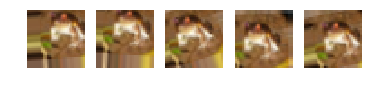

In [142]:
gen = data_gen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().astype(np.uint8).squeeze())
    plt.plot()
plt.show()